# Learning objectives

- Understand sklearn and pandas techniques for preprocessing data

https://scikit-learn.org/stable/modules/classes.html#module-sklearn.preprocessing

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns',100)
pd.set_option('display.max_rows',100)

plt.style.use('dark_background')

# Preprocessing numerical data

### Create data

In [2]:
nPts= 1000

a = np.random.normal( 1, 0.5, nPts)
b = np.random.normal(-1, 0.25, nPts) + a*1.5
X = np.array([a,b]).T

df_X = pd.DataFrame(X)
df_X

,0,1
0,1.803865,1.540045
1,0.638525,-0.014460
2,0.593528,-0.112682
3,0.736696,-0.076350
4,1.813080,1.915691
...,...,...
995,1.420035,1.062027
996,1.584747,1.354037
997,1.009223,0.208553
998,1.540584,1.493404


,count,mean,std,min,25%,50%,75%,max
0,1000.0,1.020559,0.505340,-0.503910,0.69248,1.017010,1.360425,2.829554
1,1000.0,0.538122,0.801515,-2.050292,0.04923,0.542514,1.063220,3.548346


,0,1
0,1.000000,0.953064
1,0.953064,1.000000


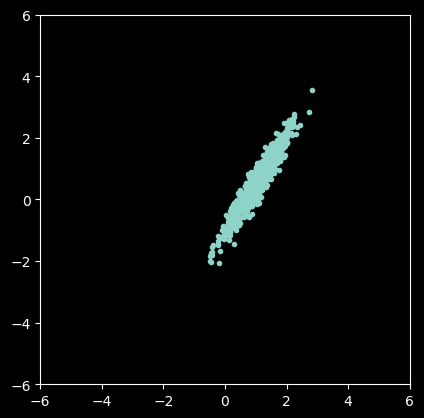

In [3]:
display(df_X.describe().T)
display(df_X.corr())

plt.plot( X[:,0], X[:,1], '.' )
plt.xlim(-6,6)
plt.ylim(-6,6)
plt.gca().set_aspect('equal')

### Standard scaler (convert to z-score: mean=0, std=1)

,count,mean,std,min,25%,50%,75%,max
0,1000.0,-5.417888e-17,1.0005,-3.018229,-0.649550,-0.007027,0.672885,3.581551
1,1000.0,-1.643130e-17,1.0005,-3.231017,-0.610265,0.005483,0.655460,3.757547


,0,1
0,1.000000,0.953064
1,0.953064,1.000000


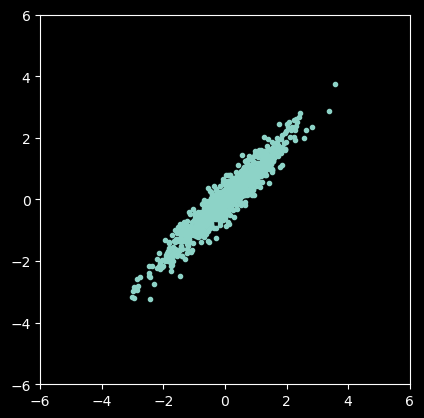

In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X1 = scaler.fit_transform(X)

df_X1 = pd.DataFrame(X1)
display(df_X1.describe().T)
display(df_X1.corr())

plt.plot( X1[:,0], X1[:,1], '.' )
plt.xlim(-6,6)
plt.ylim(-6,6)
plt.gca().set_aspect('equal')

### Min max scaler (scale values to between 0 - 1)

,count,mean,std,min,25%,50%,75%,max
0,1000.0,0.561528,0.144666,0.0,0.466395,0.562138,0.656095,1.0
1,1000.0,0.529214,0.147722,0.0,0.431372,0.529187,0.627713,1.0


,0,1
0,1.000000,0.952304
1,0.952304,1.000000


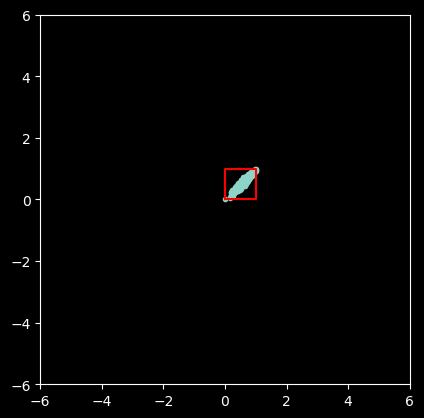

In [9]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X2 = scaler.fit_transform(X)

df_X2 = pd.DataFrame(X2)
display(df_X2.describe().T)
display(df_X2.corr())

plt.plot( X2[:,0], X2[:,1], '.' )
plt.plot( [0,1,1,0,0], [0,0,1,1,0], 'r' )
plt.xlim(-6,6)
plt.ylim(-6,6)
plt.gca().set_aspect('equal')

### PCA (principoal component analysis)

,count,mean,std,min,25%,50%,75%,max
0,1000.0,-4.263256e-17,1.398220,-4.367977,-0.884972,-0.007386,0.932801,5.189526
1,1000.0,-9.992007e-18,0.216756,-0.649322,-0.145802,-0.001347,0.130819,0.715456


,0,1
0,1.000000e+00,4.699639e-16
1,4.699639e-16,1.000000e+00


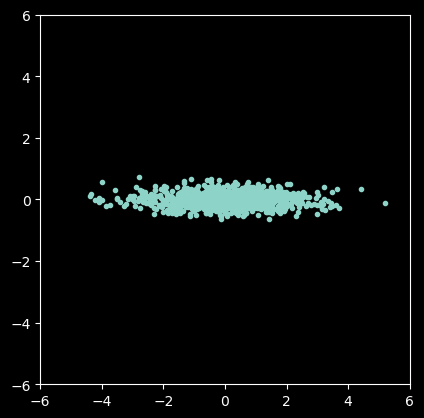

In [5]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X3 = pca.fit_transform(X1) # run PCA after std scale

df_X3 = pd.DataFrame(X3)
display(df_X3.describe().T)
display(df_X3.corr())

plt.plot( X3[:,0], X3[:,1], '.' )
plt.xlim(-6,6)
plt.ylim(-6,6)
plt.gca().set_aspect('equal')

### Binarizer (convert values to binary based on a threshold)

In [10]:
from sklearn.preprocessing import Binarizer

binarizer = Binarizer(threshold=0.5)

X4 = binarizer.fit_transform(X2)

print(X2[:4,:])
print(X4[:4,:])

[[0.25617117 0.30507337]
 [0.50092521 0.50960887]
 [0.35725264 0.36392701]
 [0.5394518  0.54113783]]
[[0. 0.]
 [1. 1.]
 [0. 0.]
 [1. 1.]]


# Preprocessing categorical data

### Create data

In [38]:
# note that this is a 1-d array
text = np.array( ['cat', 'dog', 'bird', 'cat'] )

### label encoder

In [35]:
from sklearn.preprocessing import LabelEncoder

LE = LabelEncoder()
text_LE = LE.fit_transform(text)
text_LE

array([1, 2, 0, 1], dtype=int64)

In [36]:
LE.classes_

array(['bird', 'cat', 'dog'], dtype='<U4')

In [37]:
LE.inverse_transform(text_LE)

array(['cat', 'dog', 'bird', 'cat'], dtype='<U4')

### one hot encoder

In [39]:
# note that this is a 2-d array
text2 = text[:,np.newaxis]
text2

array([['cat'],
       ['dog'],
       ['bird'],
       ['cat']], dtype='<U4')

In [40]:
from sklearn.preprocessing import OneHotEncoder

OHE = OneHotEncoder(sparse=False)
text2_OHE = OHE.fit_transform(text2)

text2_OHE

C:\Users\Graham West\anaconda3\envs\csci4900\lib\site-packages\sklearn\preprocessing\_encoders.py:972: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


array([[0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.]])

In [42]:
print(OHE.categories_)

[array(['bird', 'cat', 'dog'], dtype='<U4')]
